In [1]:
import asyncio
import time
import logging
from phoenix.otel import register
from openinference.instrumentation.langchain import LangChainInstrumentor
from portfolio_optimizer import BuildGraphAvaliacaoTics, StateClassification, BuildGraphCriadorCarteira, StateCarteira
import yfinance as yf
from typing import List
import asyncio
import pandas as pd
from bcb import sgs
import pandas as pd
from sklearn.covariance import LedoitWolf
import numpy as np
from scipy.optimize import minimize
from IPython.display import display
import matplotlib.pyplot as plt
import datetime

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

graph_tics = BuildGraphAvaliacaoTics()

graph_build = graph_tics.compile()

async def _invoke_tic(tic: str, data_inicio: str, data_fim: str):
    try:
        start = time.time()
        logger.info(f"🚀 Iniciando {tic}")
        
        result = await graph_build.ainvoke(
            StateClassification({
                "tic": tic,
                "data_inicio": data_inicio,
                "data_fim": data_fim,
                "avaliacao_analise": "",
                "description_avaliacao_analise": "",
                "interacao": 0,
            })
        )
        
        elapsed = time.time() - start
        logger.info(f"✅ {tic} concluído em {elapsed:.2f}s")
        return result
        
    except Exception as e:
        logger.error(f"❌ Erro ao processar {tic}: {e}")
        return None


async def run_all_tics(tics, data_inicio: str, data_fim: str):
    start_total = time.time()
    
    tasks = [_invoke_tic(tic, data_inicio, data_fim) for tic in tics]
    results_list = await asyncio.gather(*tasks, return_exceptions=True)
    
    elapsed_total = time.time() - start_total
    logger.info(f"⏱️  Tempo total: {elapsed_total:.2f}s")
    
    return dict(zip(tics, results_list))

def transformando_data_frame_para_markdown(results):
    try:
        results_pd = pd.DataFrame.from_dict(results).T
    except Exception as e:
        results_pd = pd.DataFrame.from_dict(results, orient="index").T
    dados_markdown = results_pd.loc[:, ["classification", "analysis"]].reset_index().rename(columns={"index": "tic"}).to_markdown()
    return dados_markdown

def correlacao(tics:List[str], data_inicio: str, data_fim: str):
    tics_yf = [tic + ".SA" for tic in tics]

    df = yf.download(tics_yf, start=data_inicio, end=data_fim, interval="1mo")["Close"]
    
    returns = df.pct_change()[4:]
    # Calcula a matriz de correlação
    correlacao = returns.corr()

    return correlacao.to_markdown()


def markowitz_opt(returns: pd.DataFrame):
    # === Estatísticas ===
    mu = returns.mean()  # retorno médio esperado
    # matriz de covariância com Ledoit–Wolf shrinkage
    lw = LedoitWolf().fit(returns)
    Sigma = lw.covariance_

    n = len(mu)

    # Retorno alvo (por exemplo, retorno médio da amostra de treino)
    target_return = mu.mean()

    # === Funções auxiliares ===
    def portfolio_performance(w, mu, Sigma):
        ret = np.dot(w, mu)
        vol = np.sqrt(np.dot(w.T, np.dot(Sigma, w)))
        return ret, vol

    def objective(w, mu, Sigma, target):
        ret, vol = portfolio_performance(w, mu, Sigma)
        return vol  # minimiza a volatilidade

    # === Restrições ===
    constraints = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},              # soma = 1
        {'type': 'eq', 'fun': lambda w: np.dot(w, mu) - target_return},  # retorno alvo
    )
    bounds = tuple((0, 1) for _ in range(n))  # sem short

    # === Otimização ===
    w0 = np.repeat(1/n, n)
    opt = minimize(
        objective, w0, args=(mu, Sigma, target_return),
        method='SLSQP', bounds=bounds, constraints=constraints
    )

    weights = opt.x

    # === Aplicação dos pesos ao conjunto de retornos ===
    markowitz_cr = (1 + (weights * returns).sum(axis=1)).cumprod()

    weights_markowitz = pd.DataFrame(
        np.tile(weights, (len(returns), 1)),  # repete o vetor em todas as linhas
        index=returns.index,
        columns=returns.columns
    )

    return weights_markowitz, markowitz_cr

def get_selic_multiplos_periodos(data_inicio, data_fim, anos_por_janela=5):
    """
    Busca dados da SELIC em janelas de X anos para contornar limitação da API
    """
    inicio = pd.to_datetime(data_inicio)
    fim = pd.to_datetime(data_fim)
    
    # Lista para armazenar os dataframes
    dados_completos = []
    
    # Criar janelas
    current_start = inicio
    
    while current_start < fim:
        current_end = min(current_start + pd.DateOffset(years=anos_por_janela), fim)
        
        print(f"Buscando dados de {current_start.date()} até {current_end.date()}...")
        
        try:
            # Fazer requisição para a janela atual
            dados_janela = sgs.get({'selic': 11, 
                                    #'cdi' :12
                                    }, 
                                   start=current_start.strftime('%Y-%m-%d'),
                                   end=current_end.strftime('%Y-%m-%d'))
            
            dados_completos.append(dados_janela)
            print(f"  ✓ {len(dados_janela)} registros obtidos")
            
        except Exception as e:
            print(f"  ✗ Erro ao buscar dados: {e}")

        current_start = current_end + pd.Timedelta(days=1)

    if dados_completos:
        selic_completo = pd.concat(dados_completos)
        selic_completo = selic_completo[~selic_completo.index.duplicated(keep='first')]
        selic_completo = selic_completo.sort_index()
        
        print(f"\n✓ Total de registros: {len(selic_completo)}")
        print(f"✓ Período: {selic_completo.index.min().date()} até {selic_completo.index.max().date()}")
        
        return selic_completo
    else:
        print("Nenhum dado foi obtido!")
        return None
    
def daily_returns(prices):
    return prices.pct_change()[1:]

def daily_returns_carteira(prices, pesos):
    pesos_porcentagem = pesos_porcentagem = [peso/100 for peso in pesos]
    variacao_diaria_carteira = (prices.pct_change()[1:] * (pesos_porcentagem)).sum(axis=1)
    return variacao_diaria_carteira

def annualized_volatility(daily_ret, trading_days=252):
    return daily_ret.std() * np.sqrt(trading_days)

def annualized_mean_return(daily_ret, trading_days=252):
    return daily_ret.mean() * trading_days

def cagr(prices):
    days = (prices.index[-1] - prices.index[0]).days
    years = days / 365.25
    return (prices.iloc[-1] / prices.iloc[0])**(1/years) - 1 if years > 0 else np.nan

def max_drawdown(prices):
    cum_max = prices.cummax()
    drawdowns = (prices - cum_max) / cum_max
    return drawdowns.min()

def avg_drawdown(prices):
    dd = (prices / prices.cummax()) - 1
    negatives = dd < 0
    groups = (negatives.astype(int).diff() != 0).cumsum()
    avg_dds = []
    for _, grp in dd.groupby(groups):
        if (grp < 0).any():
            avg_dds.append(grp.min())
    return np.mean(avg_dds) if avg_dds else 0.0

def calmar_ratio(prices):
    ann_ret = cagr(prices)
    mdd = max_drawdown(prices)
    return ann_ret / abs(mdd) if mdd != 0 else np.nan

def sortino_ratio(daily_ret, required_return=0.0, trading_days=252):
    rr_daily = (1 + required_return)**(1/trading_days) - 1
    downside = daily_ret[daily_ret < rr_daily] - rr_daily
    if downside.size == 0:
        return np.nan
    dd = np.sqrt((downside**2).mean()) * np.sqrt(trading_days)
    ann_ret = annualized_mean_return(daily_ret, trading_days)
    return (ann_ret - required_return) / dd if dd != 0 else np.nan

def compute_metrics(price_df):
    metrics = {}
    for col in price_df.columns:
        p = price_df[col].dropna()
        #dr = daily_returns_carteira(p, pesos)
        metrics[col] = {
            "ann_vol": annualized_volatility(p),
            "ann_mean_ret": annualized_mean_return(p),
            "cagr": cagr(p),
            "max_drawdown": max_drawdown(p),
            "avg_drawdown": avg_drawdown(p),
            "calmar": calmar_ratio(p),
            "sortino": sortino_ratio(p)
        }
    return pd.DataFrame(metrics).T


def normalizar_pesos(weights_dict, target_sum=100, tolerancia=0.01):
    """
    Normaliza os pesos para somarem exatamente o target_sum.
    
    Args:
        weights_dict: Dicionário com os pesos {ticker: peso}
        target_sum: Soma alvo (padrão: 100)
        tolerancia: Tolerância para considerar soma correta (padrão: 0.01)
    
    Returns:
        Dicionário com pesos normalizados
    """
    total_atual = sum(weights_dict.values())
    diferenca = abs(total_atual - target_sum)
    
    # Se já está dentro da tolerância, retorna o original
    if diferenca <= tolerancia:
        logger.info(f"✓ Pesos já somam {total_atual:.2f}% (dentro da tolerância)")
        return weights_dict
    
    # Normalização proporcional (melhor que distribuir igualmente)
    fator_normalizacao = target_sum / total_atual
    weights_normalizados = {
        ticker: peso * fator_normalizacao 
        for ticker, peso in weights_dict.items()
    }
    
    # Log da correção
    logger.warning(
        f"⚠ Pesos ajustados: {total_atual:.2f}% → {target_sum:.2f}% "
        f"(fator: {fator_normalizacao:.4f})"
    )
    
    # Verificação final
    soma_final = sum(weights_normalizados.values())
    logger.info(f"✓ Soma final: {soma_final:.4f}%")
    
    return weights_normalizados

class ComputandoMetricas:
    def __init__(self, 
                 data_inicio, 
                 data_fim, 
                 carteira,
                 valor_investido=1000):
        self.data_inicio = data_inicio
        self.data_fim = data_fim
        self.carteira = carteira
        self.valor_investido = valor_investido
        self.ibov, self.df = self.carregando_dados()
        self.tics_selecionados, self.pesos_carteira = self.ajustando_pesos_carteira()
    
        
    def carregando_dados(self):
        tics_selecionados = [tic if tic.endswith(".SA") else f"{tic}.SA" for tic in self.carteira.keys()]
        ibov = yf.download("^BVSP", start=self.data_inicio, end=self.data_fim)["Close"]
        df = yf.download(tics_selecionados, start=self.data_inicio, end=self.data_fim)["Close"]
        df.dropna(axis=1, how='all', inplace=True)
        return ibov, df
    
    def cumulative_returns(self):
        return (self.df.apply(daily_returns)+1).cumprod()
    
    def ajustando_pesos_carteira(self):
        dict_carteiras = self.carteira.copy()
        tic_validos = list(self.df.columns)
        carteira_valida = {key: value for key, value in dict_carteiras.items() if key + ".SA" in tic_validos}
        carteira_valida = {
            key: value for key, value in dict_carteiras.items()
            if (key.endswith(".SA") and key in tic_validos) or 
            (not key.endswith(".SA") and key + ".SA" in tic_validos)
        } 
        carteira_pesos_acoes_validos = normalizar_pesos(carteira_valida)
        tics_selecionados = list(carteira_pesos_acoes_validos.keys())
        pesos = list(carteira_pesos_acoes_validos.values()) 
        return tics_selecionados, pesos
        
    def computando_marcowitz(self):
        weights_markowitz, markowitz_cr = markowitz_opt(self.df.pct_change().dropna())
        return weights_markowitz, markowitz_cr
        
    def daily_returns_carteira_markowitz(self):
        weights_markowitz, markowitz_cr = self.computando_marcowitz()
        pesos_markowitz = [peso*100 for peso in weights_markowitz.iloc[-1].to_list()]
        retornos_carteira_markowitz = daily_returns_carteira(self.df, pesos_markowitz)
        return retornos_carteira_markowitz
    
    def retornos_diarios_carteira(self):
        retornos_diarios_carteira = daily_returns_carteira(self.df, self.pesos_carteira)
        return retornos_diarios_carteira
    
    def retornos_diarios_ibov(self):
        retorno_diario = self.ibov.pct_change()[1:]
        return retorno_diario
    
    def data_frame_comparacao_retorno_diario(self):
        retornos_carteira = self.retornos_diarios_carteira()
        retornos_ibov = self.retornos_diarios_ibov()
        retornos_markowitz = self.daily_returns_carteira_markowitz()
        comparacao_carteira = pd.concat([retornos_carteira, 
                                 retornos_ibov, 
                                 retornos_markowitz], axis=1,).rename(columns={0: "Carteira", 
                                                                               "^BVSP": "IBOV", 
                                                                               1: "Markowitz"})
        return comparacao_carteira
    
    def metrica_comparacao_carteira_ibov_retornos_markowitz(self):
        comparacao_carteira = self.data_frame_comparacao_retorno_diario()
        comp_metrics = compute_metrics(comparacao_carteira)
        return comp_metrics
    
    def retorno_menetario_ibov(self):
        ibov_retornos = (self.ibov.pct_change()[1:]+1).cumprod() *self.valor_investido
        return ibov_retornos
    
    def retorno_carteira_monetario(self):
        pesos_frac = [p/100 for p in self.pesos_carteira]
        valor_investido_carteira = [self.valor_investido * peso for peso in pesos_frac]
        retorno_carteira = (self.cumulative_returns() * valor_investido_carteira).sum(axis=1)
        return retorno_carteira
    
    def data_frame_comparacao_retorno_monetario(self):
        ibov_retornos = self.retorno_menetario_ibov()
        retorno_carteira = self.retorno_carteira_monetario()
        _ , markowitz_cr = self.computando_marcowitz()
        selic = self.retorno_selic()

        retorno_acumulado_monetario = pd.concat([ibov_retornos, retorno_carteira, markowitz_cr*self.valor_investido, selic], axis=1).rename(columns={"^BVSP": "IBOV", 0: "Carteira", 1: "Markowitz", "selic":"Selic"})
        return retorno_acumulado_monetario
    
    def retorno_selic(self):
        selic = get_selic_multiplos_periodos(self.data_inicio, self.data_fim)
        selic_acumulada =  ((selic/100 + 1).cumprod())*self.valor_investido
        return selic_acumulada
    
    def print_results(self, save_path="../data/"):
        import os
        from datetime import datetime
        
        # Criar diretório se não existir
        os.makedirs(save_path, exist_ok=True)
    
        
        metrics = self.metrica_comparacao_carteira_ibov_retornos_markowitz()
        retorno_acumulado_monetario = self.data_frame_comparacao_retorno_monetario()
        
        print("\n" + "="*40)
        print("📊 Métricas de Comparação das Carteiras")
        print("="*40)
        
        # Salvar métricas em CSV
        metrics_file = os.path.join(save_path, "metricas.csv")
        metrics.to_csv(metrics_file)
        print(f"✅ Métricas salvas em: {metrics_file}")
    
        display(metrics.style.set_caption("Métricas das Carteiras").background_gradient(cmap="Blues"))
    
        plt.figure(figsize=(10, 6))
        cores = {'IBOV': '#1f77b4', 'Carteira': '#2ca02c', 'Markowitz': '#d62728', 'Selic': "#d66427"}

        for nome in ['IBOV', 'Carteira', 'Markowitz', 'Selic']:
            plt.plot(
                retorno_acumulado_monetario.index,
                retorno_acumulado_monetario[nome],
                label=nome,
                color=cores[nome]
            )
            ultimo_x = retorno_acumulado_monetario.index[-2]
            ultimo_y = retorno_acumulado_monetario[nome].iloc[-2]
            plt.text(
                ultimo_x, ultimo_y,
                f'R$ {ultimo_y:,.2f}',
                color=cores[nome],
                fontsize=11,
                va='center',
                fontweight='bold'
            )

        plt.legend()
        plt.xlabel("Data")
        plt.ylabel("Retorno Monetário da Carteira")
        plt.title(f"Retorno Monetário da Carteira vs Ibov vs Markowitz (Valor inicial de R$ {self.valor_investido})")
        
        # Salvar gráfico
        grafico_file = os.path.join(save_path, f"grafico_retornos.png")
        plt.savefig(grafico_file, dpi=300, bbox_inches='tight')
        print(f"✅ Gráfico salvo em: {grafico_file}")
        
        plt.show()
        
        # Salvar retornos acumulados em CSV
        retornos_file = os.path.join(save_path, f"retornos_acumulados.csv")
        retorno_acumulado_monetario.to_csv(retornos_file)
        print(f"✅ Retornos acumulados salvos em: {retornos_file}")
        
        print("\n" + "="*40)
        
        return retorno_acumulado_monetario
    

def sequencia_datas(start, end, freq="QS"):
    data_hoje = datetime.datetime.now().strftime("%Y-%m-%d")
    periodo_datas = pd.date_range(start=start, end=data_hoje, freq=freq)
    
    datas_dict = {}
    
    for data in periodo_datas:
        novos_trimestres = pd.date_range(start=data, periods=8, freq='Q')
        data_inicio = novos_trimestres[0].strftime("%Y-%m-%d")
        data_fim = novos_trimestres[-1].strftime("%Y-%m-%d")
        
        if data_fim > data_hoje:
            data_fim = data_hoje
            datas_dict[data_inicio] = data_fim
            return datas_dict
        
        datas_dict[data_inicio] = data_fim
        
    
    return datas_dict
    

def selecionar_tics_bom_excelente(dict_tics):
    classificacao_boa = [
   "good", "excellent",
    ]
    response = {}
    for k, v in dict_tics.items():
        try:
            if v is not None and v.get('classification').lower() in classificacao_boa:
                response[k] = v
        except Exception as e:
            continue
            logger.error(f"Erro ao processar {k}: {e}")
    
    return response
    

c:\Users\jefer\Documents\Ciencia-de-dados\LLMs\Agent-Portfolio-Optimizer\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [108]:

import json
with open("../data/pesos_carteira_historico.json", "r") as f:
    results_dict = json.load(f)

In [109]:
results_dict

{'2023-03-31_to_2024-12-31': {'tickers_weights': {'CAMB3.SA': 9.09090909090909,
   'WEGE3.SA': 18.18181818181818,
   'FLRY3.SA': 13.636363636363637,
   'EGIE3.SA': 10.909090909090908,
   'ENEV3.SA': 9.09090909090909,
   'CSMG3.SA': 7.2727272727272725,
   'CGAS3.SA': 4.545454545454545,
   'ITSA3.SA': 6.363636363636363,
   'FIQE3.SA': 5.454545454545454,
   'VIVT3.SA': 6.363636363636363,
   'WIZC3.SA': 4.545454545454545,
   'HYPE3.SA': 4.545454545454545},
  'justification': "The portfolio prioritizes 'Excellent' assets (CAMB3 at 10%, WEGE3 at 20%) for higher quality. The remaining assets are selected for low correlation clusters (e.g., CGAS3 and CSMG3). WEGE3's strong fundamentals and CAMB3's low leverage reduce risk. Diversified sectors and low individual weights (none over 20%) minimize concentration. The weighted average correlation is estimated at 0.3 via sector spreads and correlations like 0.2 with WEGE3. The total Poor/PPP exposure is 0% as all assets are Good/Excellent.",
  'anali

# Criando pesos marcowitz

In [53]:
import yfinance as yf
import logging
import pandas as pd
import datetime
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

In [67]:
pesos_carteira_marcowitz = {}

for key, value in results_dict.items(): 
    
    acoes = list(value['tickers_weights'].keys())
    
    acoes_sa = [acao if acao.endswith(".SA") else f"{acao}.SA"  for acao in acoes]
    
    data_split = key.split("_to_")
    
    start = data_split[0]
    
    end = data_split[1]
    try:
    
        comp = ComputandoMetricas(str(start), str(end), value['tickers_weights'],1000)
            
        weights_markowitz, _ = comp.computando_marcowitz()
            
        computando_marcowitz = weights_markowitz.iloc[-1].to_dict()
            
        pesos_carteira_marcowitz[f"{start}_to_{end}"] = computando_marcowitz
    except Exception as e:
        logger.error(f"Erro ao computar Markowitz para o período {start} a {end}: {e}")
        continue

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  4 of 4 completed
INFO:__main__:✓ Pesos já somam 100.00% (dentro da tolerância)
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  3 of 3 completed
INFO:__main__:✓ Pesos já somam 100.00% (dentro da tolerância)
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
INFO:__main__:✓ Pesos já somam 100.00% (dentro da tolerância)
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
INFO:__main__:✓ Pesos já somam 100.00% (dentro da tolerância)
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  5 of 5 completed
INFO:__main__:✓ Pesos já somam 100.00% (dentro da tolerância)


In [68]:
pesos_carteira_marcowitz

{'2023-03-31_to_2024-12-31': {'GGBR4.SA': 0.31724262968587547,
  'LREN3.SA': 0.019616721392271615,
  'PETR4.SA': 0.17549557572768434,
  'VIVT3.SA': 0.4876450731941686},
 '2023-06-30_to_2025-03-31': {'ITUB4.SA': 0.23973653264844683,
  'LREN3.SA': 0.31676295257733933,
  'VIVT3.SA': 0.44350051477421387},
 '2023-09-30_to_2025-06-30': {'ABEV3.SA': 1.0},
 '2023-12-31_to_2025-09-30': {'VIVT3.SA': 1.0},
 '2024-03-31_to_2025-12-29': {'ITUB4.SA': 0.2013462028945901,
  'LREN3.SA': 0.0,
  'PETR4.SA': 0.39826276285263973,
  'PSSA3.SA': 0.18310191392354042,
  'VIVT3.SA': 0.2172891203292298}}

# Coletando dados dos proximos trimestres dos tickers selecionados

In [72]:

precos_carteira = {}

for key, value in results_dict.items():
    
    acoes = list(value['tickers_weights'].keys())
    
    acoes_sa = [acao if acao.endswith(".SA") else f"{acao}.SA"  for acao in acoes]
    
    data_split = key.split("_to_")

    start = data_split[1]
    
    data = pd.Timestamp(start)
    
    end = data + pd.DateOffset(months=3)
    
    end = end.strftime("%Y-%m-%d")
    
    date_now = datetime.datetime.now().strftime("%Y-%m-%d")
    
    if end > date_now:
        logger.info("Data final da carteira maior que a data atual, ajustando para a data atual.")
        end = date_now

        
    logger.info(f"Baixando dados de {start} a {end}, para as acoes {acoes_sa}")
    
    precos_carteira[f"{start}"] = yf.download(acoes_sa, start=str(start), end= str(end))["Close"]
    
    pesos = list(value['tickers_weights'].values())
    
    


precos_carteira_marcowitz = {}

for key, value in pesos_carteira_marcowitz.items():
    acoes = list(value.keys())
    acoes_sa = [acao if acao.endswith(".SA") else f"{acao}.SA"  for acao in acoes]
    
    data_split = key.split("_to_")

    start = data_split[1]
    
    data = pd.Timestamp(start)
    
    end = data + pd.DateOffset(months=3)
    
    end = end.strftime("%Y-%m-%d")
    
    date_now = datetime.datetime.now().strftime("%Y-%m-%d")
    
    if end > date_now:
        logger.info("Data final da carteira maior que a data atual, ajustando para a data atual.")
        end = date_now
    logger.info(f"Baixando dados de {start} a {end}, para as acoes {acoes_sa}")
    precos_carteira_marcowitz[f'{start}'] = yf.download(acoes_sa, start=str(start), end= str(end))["Close"]

INFO:__main__:Baixando dados de 2024-12-31 a 2025-03-31, para as acoes ['PETR4.SA', 'GGBR4.SA', 'LREN3.SA', 'VIVT3.SA']
[*********************100%***********************]  4 of 4 completed
INFO:__main__:Baixando dados de 2025-03-31 a 2025-06-30, para as acoes ['ITUB4.SA', 'LREN3.SA', 'VIVT3.SA']
[*********************100%***********************]  3 of 3 completed
INFO:__main__:Baixando dados de 2025-06-30 a 2025-09-30, para as acoes ['ABEV3.SA']
[*********************100%***********************]  1 of 1 completed
INFO:__main__:Baixando dados de 2025-09-30 a 2025-12-30, para as acoes ['VIVT3.SA']
[*********************100%***********************]  1 of 1 completed
INFO:__main__:Data final da carteira maior que a data atual, ajustando para a data atual.
INFO:__main__:Baixando dados de 2025-12-29 a 2025-12-31, para as acoes ['PETR4.SA', 'ITUB4.SA', 'LREN3.SA', 'PSSA3.SA', 'VIVT3.SA']
[*********************100%***********************]  5 of 5 completed
INFO:__main__:Baixando dados de 2024-

In [73]:
pesos_carteira_marcowitz

{'2023-03-31_to_2024-12-31': {'GGBR4.SA': 0.31724262968587547,
  'LREN3.SA': 0.019616721392271615,
  'PETR4.SA': 0.17549557572768434,
  'VIVT3.SA': 0.4876450731941686},
 '2023-06-30_to_2025-03-31': {'ITUB4.SA': 0.23973653264844683,
  'LREN3.SA': 0.31676295257733933,
  'VIVT3.SA': 0.44350051477421387},
 '2023-09-30_to_2025-06-30': {'ABEV3.SA': 1.0},
 '2023-12-31_to_2025-09-30': {'VIVT3.SA': 1.0},
 '2024-03-31_to_2025-12-29': {'ITUB4.SA': 0.2013462028945901,
  'LREN3.SA': 0.0,
  'PETR4.SA': 0.39826276285263973,
  'PSSA3.SA': 0.18310191392354042,
  'VIVT3.SA': 0.2172891203292298}}

In [74]:
precos_carteira_marcowitz

{'2024-12-31': Ticker       GGBR4.SA   LREN3.SA   PETR4.SA   VIVT3.SA
 Date                                                  
 2025-01-02  17.272533  11.347687  33.027279  22.255062
 2025-01-03  16.703533  11.489532  32.676979  22.160484
 2025-01-06  17.388264  11.848875  32.524281  22.576637
 2025-01-07  17.301466  12.359522  33.215904  23.040092
 2025-01-08  16.973570  12.170395  32.946442  22.344917
 2025-01-09  16.491364  12.293326  33.090153  22.666496
 2025-01-10  16.202042  12.142025  33.179977  22.165213
 2025-01-13  16.385279  12.151482  33.296741  22.151024
 2025-01-14  16.462433  11.924527  33.072193  22.311815
 2025-01-15  17.021786  12.482455  33.494350  23.096840
 2025-01-16  16.645670  11.735398  33.278778  22.936054
 2025-01-17  16.751755  11.659748  33.413517  23.219795
 2025-01-20  16.906057  11.725943  33.494350  23.191423
 2025-01-21  17.272533  11.839420  33.503334  23.560291
 2025-01-22  16.973570  12.416262  33.314709  23.929161
 2025-01-23  16.838549  12.293326 

In [75]:
def daily_returns(prices):
    return prices.pct_change()[1:]

def cumulative_returns(df):
    return (df.apply(daily_returns)+1).cumprod()

def retorno_carteira_monetario(df, pesos, valor_investido):
    pesos_frac = [p/100 for p in pesos]
    valor_investido_carteira = [valor_investido * peso for peso in pesos_frac]
    retorno_carteira = (cumulative_returns(df) * valor_investido_carteira).sum(axis=1)
    return retorno_carteira

def retorno_percentual_acao_individual(pesos_carteiras, precos_carteira):
    """pesos_frac = [p/100 for p in pesos_carteiras[chaves[keys]].values()]
    valor_investido_carteira = [1000 * peso for peso in pesos_frac]
    retorno_carteira = (cumulative_returns(precos_carteira[chaves[keys]]) * valor_investido_carteira)"""
    
    
    pesos_frac = [p/100 for p in pesos_carteiras.values()]
    valor_investido_carteira = [1000 * peso for peso in pesos_frac]
    
    # Usar diretamente precos_df (já é o DataFrame correto)
    retorno_carteira = cumulative_returns(precos_carteira) * valor_investido_carteira
    
    retorno_percentual = retorno_carteira.apply(
        lambda x: (x.iloc[-1] - x.iloc[0]) / x.iloc[0] * 100
    )
    return retorno_percentual

In [76]:
precos_carteira

{'2024-12-31': Ticker       GGBR4.SA   LREN3.SA   PETR4.SA   VIVT3.SA
 Date                                                  
 2025-01-02  17.272533  11.347687  33.027279  22.255062
 2025-01-03  16.703533  11.489532  32.676979  22.160484
 2025-01-06  17.388264  11.848875  32.524281  22.576637
 2025-01-07  17.301466  12.359522  33.215904  23.040092
 2025-01-08  16.973570  12.170395  32.946442  22.344917
 2025-01-09  16.491364  12.293326  33.090153  22.666496
 2025-01-10  16.202042  12.142025  33.179977  22.165213
 2025-01-13  16.385279  12.151482  33.296741  22.151024
 2025-01-14  16.462433  11.924527  33.072193  22.311815
 2025-01-15  17.021786  12.482455  33.494350  23.096840
 2025-01-16  16.645670  11.735398  33.278778  22.936054
 2025-01-17  16.751755  11.659748  33.413517  23.219795
 2025-01-20  16.906057  11.725943  33.494350  23.191423
 2025-01-21  17.272533  11.839420  33.503334  23.560291
 2025-01-22  16.973570  12.416262  33.314709  23.929161
 2025-01-23  16.838549  12.293326 

In [77]:
def verificando_valores_nulos(pesos_carteiras, precos_carteira):
    #dict_keys = pesos_carteiras[values]['tickers_weights'].copy()
    null = precos_carteira.isna().any()
    list_name_null = precos_carteira.loc[:,null].columns.to_list()
    
    dict_keys = {
        (key if key.endswith(".SA") else f"{key}.SA"): value 
        for key, value in pesos_carteiras.items()
    }
    valor_do_tic_null = 0
    for tic in list_name_null:
        valor_do_tic_null += dict_keys[tic]
        dict_keys.pop(tic)  
    
    quantidade_sobrou = len(dict_keys)
    
    if quantidade_sobrou == 0:
        return {}  # Evitar divisão por zero
    
    valor_para_cada_tic = valor_do_tic_null / quantidade_sobrou
    
    dict_com_novos_valores = {}
    for key, value in dict_keys.items():
        dict_com_novos_valores[key] = value + valor_para_cada_tic
    
    return dict_com_novos_valores

In [101]:
from IPython.display import display, Markdown
import pandas as pd
carteira = pd.DataFrame()
carteira_marcowitz = pd.DataFrame()

interacoes = 0

for key, value in results_dict.items():
    data_split = key.split("_to_")
    start = data_split[0]
    end = data_split[1]
    print("*" * 40)
    display(Markdown(f"**O retorno da carteira para o período: {key}**"))
    
    pesos_carteira = value['tickers_weights']
    
    precos_carteira_selecionada = precos_carteira[end]
    
    pesos_sem_erro = verificando_valores_nulos(pesos_carteira, precos_carteira_selecionada)
    
    precos_sem_nan = precos_carteira[end].dropna(axis=1)
    
    carteira_percentual_acoes = retorno_percentual_acao_individual(pesos_sem_erro, precos_sem_nan)
    
    try:
        pesos_carteira_marcowitz_selecionada = pesos_carteira_marcowitz[key]
        precos_carteira_marcowitz_selecionada = precos_carteira_marcowitz[end]
        pesos_sem_erro_markowitz = verificando_valores_nulos(pesos_carteira_marcowitz_selecionada, precos_carteira_marcowitz_selecionada)
        pesos_sem_erro_markowitz = {key_: value*100 for key_, value in pesos_sem_erro_markowitz.items()}
    
        precos_sem_nan_markwitz = precos_carteira_marcowitz[end].dropna(axis=1)
    
        carteira_percentual_acoes_marcowitz = retorno_percentual_acao_individual(pesos_sem_erro_markowitz, precos_sem_nan_markwitz)
    except Exception as e:  
        logger.info(f"Erro ao obter:{e}")
    
    data = pd.DataFrame(pesos_sem_erro, index=["Pesos"]).T
    data_markwitz = pd.DataFrame(pesos_sem_erro_markowitz, index=["Pesos"]).T
    
    if not carteira_percentual_acoes.empty:
        data['retornos em %'] = pd.DataFrame(carteira_percentual_acoes)
        data_markwitz['retornos markwitz em %'] = pd.DataFrame(carteira_percentual_acoes_marcowitz)
    else:
        print("Nenhum dado foi obtido!")
        
    display(data.T.style.set_caption("Pesos").background_gradient(cmap="Blues"))
    
    display(data_markwitz.T.style.set_caption("Pesos").background_gradient(cmap="Blues"))
    
    if interacoes == 0:
        valor_carteira = retorno_carteira_monetario(precos_sem_nan, pesos_sem_erro.values(), 1000)
        
        valor_carteira_markwitz = retorno_carteira_monetario(precos_sem_nan_markwitz, pesos_sem_erro_markowitz.values(), 1000)

        
    else:   
        valor_carteira = retorno_carteira_monetario(precos_sem_nan, pesos_sem_erro.values(), valor_atual_carteira)
        
        valor_carteira_markwitz = retorno_carteira_monetario(precos_sem_nan_markwitz, pesos_sem_erro_markowitz.values(), valor_atual_carteira_markwitz)
    
    carteira = pd.concat([carteira, valor_carteira])
    carteira_marcowitz = pd.concat([carteira_marcowitz, valor_carteira_markwitz])
    
    try:
        valor_atual_carteira = int(valor_carteira.iloc[-1])
        valor_atual_carteira_markwitz = int(valor_carteira_markwitz.iloc[-1])
    
    except:
        pass
    
    interacoes = interacoes + 1
    

****************************************


**O retorno da carteira para o período: 2023-03-31_to_2024-12-31**

,PETR4.SA,GGBR4.SA,LREN3.SA,VIVT3.SA
Pesos,26.315789,21.052632,26.315789,26.315789
retornos em %,2.886200,-1.835715,4.763561,10.219068


,GGBR4.SA,LREN3.SA,PETR4.SA,VIVT3.SA
Pesos,31.724263,1.961672,17.549558,48.764507
retornos markwitz em %,-1.835715,4.763561,2.886200,10.219068


****************************************


...

,VIVT3.SA
Pesos,100.000000
retornos markwitz em %,-2.179756


****************************************


**O retorno da carteira para o período: 2024-03-31_to_2025-12-29**

,PETR4.SA,ITUB4.SA,LREN3.SA,PSSA3.SA,VIVT3.SA
Pesos,15.000000,20.000000,20.000000,20.000000,25.000000
retornos em %,0.000000,0.000000,0.000000,0.000000,0.000000


,ITUB4.SA,LREN3.SA,PETR4.SA,PSSA3.SA,VIVT3.SA
Pesos,20.134620,0.000000,39.826276,18.310191,21.728912
retornos markwitz em %,0.000000,nan,0.000000,0.000000,0.000000


In [15]:
"""from IPython.display import display, Markdown

carteira = pd.DataFrame()
carteira_marcowitz = pd.DataFrame()
for key, value in enumerate(chaves):
    
    print("*" * 40)
    
    display(Markdown(f"**O retorno da carteira para o período: {value}**"))
    
    ## Pesos selecionados pelo modelo
    pesos_sem_erro = verificando_valores_nulos(value, pesos_carteiras, precos_carteira)
    
    precos_sem_nan = precos_carteira[chaves[key]].dropna(axis=1)
    
    carteira_percentual_acoes = retorno_percentual_acao_individual(pesos_sem_erro, precos_sem_nan)
    
    # carteira de markowits
    try:
        pesos_sem_erro_markowitz = verificando_valores_nulos(value, pesos_carteira_marcowitz, precos_carteira_marcowitz)
        pesos_sem_erro_markowitz = {key_: value*100 for key_, value in pesos_sem_erro_markowitz.items()}
    
        precos_sem_nan_markwitz = precos_carteira_marcowitz[chaves[key]].dropna(axis=1)
    
        carteira_percentual_acoes_marcowitz = retorno_percentual_acao_individual(pesos_sem_erro_markowitz, precos_sem_nan_markwitz)
    except Exception as e:  
        logger.info(f"Erro ao obter:{e}")
    
    data = pd.DataFrame(pesos_sem_erro, index=["Pesos"]).T
    data_markwitz = pd.DataFrame(pesos_sem_erro_markowitz, index=["Pesos"]).T
    
    if not carteira_percentual_acoes.empty:
        data['retornos em %'] = pd.DataFrame(carteira_percentual_acoes)
        data_markwitz['retornos markwitz em %'] = pd.DataFrame(carteira_percentual_acoes_marcowitz)
    else:
        print("Nenhum dado foi obtido!")
        
    display(data.T.style.set_caption("Pesos").background_gradient(cmap="Blues"))
    
    display(data_markwitz.T.style.set_caption("Pesos").background_gradient(cmap="Blues"))

    if key == 0:
        valor_carteira = retorno_carteira_monetario(precos_sem_nan, pesos_sem_erro.values(), 1000)
        
        valor_carteira_markwitz = retorno_carteira_monetario(precos_sem_nan_markwitz, pesos_sem_erro_markowitz.values(), 1000)

        
    else:   
        valor_carteira = retorno_carteira_monetario(precos_sem_nan, pesos_sem_erro.values(), valor_atual_carteira)
        
        valor_carteira_markwitz = retorno_carteira_monetario(precos_sem_nan_markwitz, pesos_sem_erro_markowitz.values(), valor_atual_carteira_markwitz)
    
    carteira = pd.concat([carteira, valor_carteira])
    carteira_marcowitz = pd.concat([carteira_marcowitz, valor_carteira_markwitz])
    
    try:
        valor_atual_carteira = int(valor_carteira.iloc[-1])
        valor_atual_carteira_markwitz = int(valor_carteira_markwitz.iloc[-1])
    
    except:
        pass
    
    
     
    """

'from IPython.display import display, Markdown\n\ncarteira = pd.DataFrame()\ncarteira_marcowitz = pd.DataFrame()\nfor key, value in enumerate(chaves):\n\n    print("*" * 40)\n\n    display(Markdown(f"**O retorno da carteira para o período: {value}**"))\n\n    ## Pesos selecionados pelo modelo\n    pesos_sem_erro = verificando_valores_nulos(value, pesos_carteiras, precos_carteira)\n\n    precos_sem_nan = precos_carteira[chaves[key]].dropna(axis=1)\n\n    carteira_percentual_acoes = retorno_percentual_acao_individual(pesos_sem_erro, precos_sem_nan)\n\n    # carteira de markowits\n    try:\n        pesos_sem_erro_markowitz = verificando_valores_nulos(value, pesos_carteira_marcowitz, precos_carteira_marcowitz)\n        pesos_sem_erro_markowitz = {key_: value*100 for key_, value in pesos_sem_erro_markowitz.items()}\n\n        precos_sem_nan_markwitz = precos_carteira_marcowitz[chaves[key]].dropna(axis=1)\n\n        carteira_percentual_acoes_marcowitz = retorno_percentual_acao_individual(pes

In [83]:
precos_carteira.keys()

dict_keys(['2024-12-31', '2025-03-31', '2025-06-30', '2025-09-30', '2025-12-29'])

In [84]:
datas_lista = list(precos_carteira.keys())

In [86]:
start_bove = datas_lista[0]
end_bove = datas_lista[-1]
end_bove

'2025-12-29'

In [87]:
start_bove

'2024-12-31'

In [88]:
import pandas as pd
from bcb import sgs

def get_selic_multiplos_periodos(data_inicio, data_fim, anos_por_janela=5):
    """
    Busca dados da SELIC em janelas de X anos para contornar limitação da API
    """
    inicio = pd.to_datetime(data_inicio)
    fim = pd.to_datetime(data_fim)
    
    # Lista para armazenar os dataframes
    dados_completos = []
    
    # Criar janelas
    current_start = inicio
    
    while current_start < fim:
        current_end = min(current_start + pd.DateOffset(years=anos_por_janela), fim)
        
        print(f"Buscando dados de {current_start.date()} até {current_end.date()}...")
        
        try:
            # Fazer requisição para a janela atual
            dados_janela = sgs.get({'selic': 11, 
                                    #'cdi' :12
                                    }, 
                                   start=current_start.strftime('%Y-%m-%d'),
                                   end=current_end.strftime('%Y-%m-%d'))
            
            dados_completos.append(dados_janela)
            print(f"  ✓ {len(dados_janela)} registros obtidos")
            
        except Exception as e:
            print(f"  ✗ Erro ao buscar dados: {e}")

        current_start = current_end + pd.Timedelta(days=1)

    if dados_completos:
        selic_completo = pd.concat(dados_completos)
        selic_completo = selic_completo[~selic_completo.index.duplicated(keep='first')]
        selic_completo = selic_completo.sort_index()
        
        print(f"\n✓ Total de registros: {len(selic_completo)}")
        print(f"✓ Período: {selic_completo.index.min().date()} até {selic_completo.index.max().date()}")
        
        return selic_completo
    else:
        print("Nenhum dado foi obtido!")
        return None

# Usar a função
selic = get_selic_multiplos_periodos(start_bove, end_bove)


Buscando dados de 2024-12-31 até 2025-12-29...
  ✓ 251 registros obtidos

✓ Total de registros: 251
✓ Período: 2024-12-31 até 2025-12-29


In [89]:
selic

,selic
Date,
2024-12-31,0.045513
2025-01-02,0.045513
2025-01-03,0.045513
2025-01-06,0.045513
2025-01-07,0.045513
...,...
2025-12-22,0.055131
2025-12-23,0.055131
2025-12-24,0.055131


In [90]:
selic_acumulada =  ((selic/100 + 1).cumprod())*1000
selic_acumulada

,selic
Date,
2024-12-31,1000.455130
2025-01-02,1000.910467
2025-01-03,1001.366012
2025-01-06,1001.821763
2025-01-07,1002.277722
...,...
2025-12-22,1139.986476
2025-12-23,1140.614962
2025-12-24,1141.243794


In [91]:
carteira

,0
2025-01-03,990.052978
2025-01-06,1010.856116
2025-01-07,1029.998371
2025-01-08,1011.126678
2025-01-09,1011.008257
...,...
2025-12-22,1243.328162
2025-12-23,1247.924569
2025-12-26,1264.778061
2025-12-29,1265.544202


In [92]:
ibov = yf.download("^BVSP", start=start_bove, end=end_bove)["Close"]
ibov_retornos = (ibov.pct_change()+1).cumprod()*1000
ibov_retornos

[*********************100%***********************]  1 of 1 completed


Ticker,^BVSP
Date,
2025-01-02,NaN
2025-01-03,986.747138
2025-01-06,999.142560
2025-01-07,1008.640999
2025-01-08,995.837669
...,...
2025-12-18,1314.655567
2025-12-19,1319.234131
2025-12-22,1316.478668


In [93]:
carteira

,0
2025-01-03,990.052978
2025-01-06,1010.856116
2025-01-07,1029.998371
2025-01-08,1011.126678
2025-01-09,1011.008257
...,...
2025-12-22,1243.328162
2025-12-23,1247.924569
2025-12-26,1264.778061
2025-12-29,1265.544202


In [94]:
retorno_acumulado_monetario = pd.concat([selic_acumulada, ibov_retornos], axis=1).rename(columns={"selic": "Selic", "^BVSP": "IBOV"})
carteira_marcowitz = carteira_marcowitz[~carteira_marcowitz.index.duplicated(keep='last')]
carteira = carteira[~carteira.index.duplicated(keep='last')]
retorno_acumulado_monetario['Markowitz'] = carteira_marcowitz
retorno_acumulado_monetario['Carteira'] = carteira

In [95]:
retorno_acumulado_monetario = retorno_acumulado_monetario.dropna()

In [96]:
retorno_acumulado_monetario

,Selic,IBOV,Markowitz,Carteira
Date,,,,
2025-01-03,1001.366012,986.747138,985.860717,990.052978
2025-01-06,1001.821763,999.142560,1007.365490,1010.856116
2025-01-07,1002.277722,1008.640999,1020.484157,1029.998371
2025-01-08,1002.733889,995.837669,997.470519,1011.126678
2025-01-09,1003.190263,997.136316,996.636358,1011.008257
...,...,...,...,...
2025-12-18,1138.730543,1314.655567,1270.253923,1260.564725
2025-12-19,1139.358336,1319.234131,1266.780084,1257.117383
2025-12-22,1139.986476,1316.478668,1252.884873,1243.328162


In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===============================================================
# MÉTRICAS
# ===============================================================

def daily_returns(prices):
    return prices.pct_change()[1:]

def annualized_volatility(daily_ret, trading_days=252):
    return daily_ret.std() * np.sqrt(trading_days)

def annualized_mean_return(daily_ret, trading_days=252):
    return daily_ret.mean() * trading_days

def cagr(prices):
    days = (prices.index[-1] - prices.index[0]).days
    years = days / 365.25
    return (prices.iloc[-1] / prices.iloc[0])**(1/years) - 1 if years > 0 else np.nan

def max_drawdown(prices):
    cum_max = prices.cummax()
    drawdowns = (prices - cum_max) / cum_max
    return drawdowns.min()

def avg_drawdown(prices):
    dd = (prices / prices.cummax()) - 1
    negatives = dd < 0
    groups = (negatives.astype(int).diff() != 0).cumsum()
    avg_dds = []
    for _, grp in dd.groupby(groups):
        if (grp < 0).any():
            avg_dds.append(grp.min())
    return np.mean(avg_dds) if avg_dds else 0.0

def calmar_ratio(prices):
    ann_ret = cagr(prices)
    mdd = max_drawdown(prices)
    return ann_ret / abs(mdd) if mdd != 0 else np.nan

def sortino_ratio(daily_ret, required_return=0.0, trading_days=252):
    rr_daily = (1 + required_return)**(1/trading_days) - 1
    downside = daily_ret[daily_ret < rr_daily] - rr_daily
    if downside.size == 0:
        return np.nan
    dd = np.sqrt((downside**2).mean()) * np.sqrt(trading_days)
    ann_ret = annualized_mean_return(daily_ret, trading_days)
    return (ann_ret - required_return) / dd if dd != 0 else np.nan

def compute_metrics(price_df):
    metrics = {}
    for col in price_df.columns:
        p = price_df[col].dropna()
        dr = daily_returns(p)
        metrics[col] = {
            "ann_vol": annualized_volatility(dr),
            "ann_mean_ret": annualized_mean_return(dr),
            "cagr": cagr(p),
            "max_drawdown": max_drawdown(p),
            "avg_drawdown": avg_drawdown(p),
            "calmar": calmar_ratio(p),
            "sortino": sortino_ratio(dr)
        }
    return pd.DataFrame(metrics).T

In [99]:
compute_metrics(retorno_acumulado_monetario).style.set_caption("Métricas das Carteiras").background_gradient(cmap="Blues")

,ann_vol,ann_mean_ret,cagr,max_drawdown,avg_drawdown,calmar,sortino
Selic,0.001227,0.136205,0.143781,0.000000,0.000000,nan,nan
IBOV,0.153133,0.328764,0.367022,-0.069223,-0.018941,5.302007,2.247832
Markowitz,0.220464,0.290767,0.300473,-0.129484,-0.028664,2.320549,1.222965
Carteira,0.225183,0.279463,0.284735,-0.129177,-0.031289,2.204221,1.148250


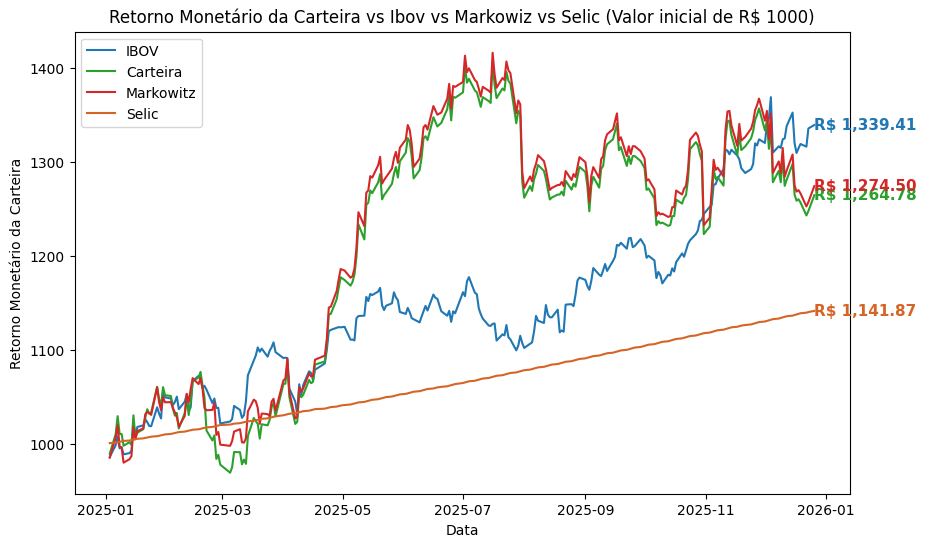

In [100]:
from matplotlib import pyplot as plt
plt.figure(figsize=(10, 6))
cores = {'IBOV': '#1f77b4', 'Carteira': '#2ca02c', 'Markowitz': '#d62728', 'Selic': "#d66427"}
retorno_acumulado_monetario = retorno_acumulado_monetario.dropna()
for nome in ['IBOV', 
             'Carteira', 
             'Markowitz', 
             'Selic']:
    plt.plot(
            retorno_acumulado_monetario.index,
            retorno_acumulado_monetario[nome],
                label=nome,
                color=cores[nome]
            )
    ultimo_x = retorno_acumulado_monetario[nome].index[-1]
    ultimo_y = retorno_acumulado_monetario[nome].iloc[-1]
    plt.text(
                ultimo_x, ultimo_y,
                f'R$ {ultimo_y:,.2f}',
                color=cores[nome],
                fontsize=11,
                va='center',
                fontweight='bold'
            )

plt.legend()
plt.xlabel("Data")
plt.ylabel("Retorno Monetário da Carteira")
plt.title(f"Retorno Monetário da Carteira vs Ibov vs Markowiz vs Selic (Valor inicial de R$ {1000})")
plt.show()

In [ ]:
import json
import asyncio
import pandas as pd
from bcb import sgs
import pandas as pd
from sklearn.covariance import LedoitWolf
import numpy as np
from scipy.optimize import minimize
from IPython.display import display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

    
def markowitz_opt(returns: pd.DataFrame):
    # === Estatísticas ===
    mu = returns.mean()  # retorno médio esperado
    # matriz de covariância com Ledoit–Wolf shrinkage
    lw = LedoitWolf().fit(returns)
    Sigma = lw.covariance_

    n = len(mu)

    # Retorno alvo (por exemplo, retorno médio da amostra de treino)
    target_return = mu.mean()

    # === Funções auxiliares ===
    def portfolio_performance(w, mu, Sigma):
        ret = np.dot(w, mu)
        vol = np.sqrt(np.dot(w.T, np.dot(Sigma, w)))
        return ret, vol

    def objective(w, mu, Sigma, target):
        ret, vol = portfolio_performance(w, mu, Sigma)
        return vol  # minimiza a volatilidade

    # === Restrições ===
    constraints = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},              # soma = 1
        {'type': 'eq', 'fun': lambda w: np.dot(w, mu) - target_return},  # retorno alvo
    )
    bounds = tuple((0, 1) for _ in range(n))  # sem short

    # === Otimização ===
    w0 = np.repeat(1/n, n)
    opt = minimize(
        objective, w0, args=(mu, Sigma, target_return),
        method='SLSQP', bounds=bounds, constraints=constraints
    )

    weights = opt.x

    # === Aplicação dos pesos ao conjunto de retornos ===
    markowitz_cr = (1 + (weights * returns).sum(axis=1)).cumprod()

    weights_markowitz = pd.DataFrame(
        np.tile(weights, (len(returns), 1)),  # repete o vetor em todas as linhas
        index=returns.index,
        columns=returns.columns
    )

    return weights_markowitz, markowitz_cr

def get_selic_multiplos_periodos(data_inicio, data_fim, anos_por_janela=5):
    """
    Busca dados da SELIC em janelas de X anos para contornar limitação da API
    """
    inicio = pd.to_datetime(data_inicio)
    fim = pd.to_datetime(data_fim)
    
    # Lista para armazenar os dataframes
    dados_completos = []
    
    # Criar janelas
    current_start = inicio
    
    while current_start < fim:
        current_end = min(current_start + pd.DateOffset(years=anos_por_janela), fim)
        
        print(f"Buscando dados de {current_start.date()} até {current_end.date()}...")
        
        try:
            # Fazer requisição para a janela atual
            dados_janela = sgs.get({'selic': 11, 
                                    #'cdi' :12
                                    }, 
                                   start=current_start.strftime('%Y-%m-%d'),
                                   end=current_end.strftime('%Y-%m-%d'))
            
            dados_completos.append(dados_janela)
            print(f"  ✓ {len(dados_janela)} registros obtidos")
            
        except Exception as e:
            print(f"  ✗ Erro ao buscar dados: {e}")

        current_start = current_end + pd.Timedelta(days=1)

    if dados_completos:
        selic_completo = pd.concat(dados_completos)
        selic_completo = selic_completo[~selic_completo.index.duplicated(keep='first')]
        selic_completo = selic_completo.sort_index()
        
        print(f"\n✓ Total de registros: {len(selic_completo)}")
        print(f"✓ Período: {selic_completo.index.min().date()} até {selic_completo.index.max().date()}")
        
        return selic_completo
    else:
        print("Nenhum dado foi obtido!")
        return None
    
def daily_returns(prices):
    return prices.pct_change()[1:]

def daily_returns_carteira(prices, pesos):
    pesos_porcentagem = pesos_porcentagem = [peso/100 for peso in pesos]
    variacao_diaria_carteira = (prices.pct_change()[1:] * (pesos_porcentagem)).sum(axis=1)
    return variacao_diaria_carteira

def annualized_volatility(daily_ret, trading_days=252):
    return daily_ret.std() * np.sqrt(trading_days)

def annualized_mean_return(daily_ret, trading_days=252):
    return daily_ret.mean() * trading_days

def cagr(prices):
    days = (prices.index[-1] - prices.index[0]).days
    years = days / 365.25
    return (prices.iloc[-1] / prices.iloc[0])**(1/years) - 1 if years > 0 else np.nan

def max_drawdown(prices):
    cum_max = prices.cummax()
    drawdowns = (prices - cum_max) / cum_max
    return drawdowns.min()

def avg_drawdown(prices):
    dd = (prices / prices.cummax()) - 1
    negatives = dd < 0
    groups = (negatives.astype(int).diff() != 0).cumsum()
    avg_dds = []
    for _, grp in dd.groupby(groups):
        if (grp < 0).any():
            avg_dds.append(grp.min())
    return np.mean(avg_dds) if avg_dds else 0.0

def calmar_ratio(prices):
    ann_ret = cagr(prices)
    mdd = max_drawdown(prices)
    return ann_ret / abs(mdd) if mdd != 0 else np.nan

def sortino_ratio(daily_ret, required_return=0.0, trading_days=252):
    rr_daily = (1 + required_return)**(1/trading_days) - 1
    downside = daily_ret[daily_ret < rr_daily] - rr_daily
    if downside.size == 0:
        return np.nan
    dd = np.sqrt((downside**2).mean()) * np.sqrt(trading_days)
    ann_ret = annualized_mean_return(daily_ret, trading_days)
    return (ann_ret - required_return) / dd if dd != 0 else np.nan

def compute_metrics(price_df):
    metrics = {}
    for col in price_df.columns:
        p = price_df[col].dropna()
        #dr = daily_returns_carteira(p, pesos)
        metrics[col] = {
            "ann_vol": annualized_volatility(p),
            "ann_mean_ret": annualized_mean_return(p),
            "cagr": cagr(p),
            "max_drawdown": max_drawdown(p),
            "avg_drawdown": avg_drawdown(p),
            "calmar": calmar_ratio(p),
            "sortino": sortino_ratio(p)
        }
    return pd.DataFrame(metrics).T


def normalizar_pesos(weights_dict, target_sum=100, tolerancia=0.01):
    """
    Normaliza os pesos para somarem exatamente o target_sum.
    
    Args:
        weights_dict: Dicionário com os pesos {ticker: peso}
        target_sum: Soma alvo (padrão: 100)
        tolerancia: Tolerância para considerar soma correta (padrão: 0.01)
    
    Returns:
        Dicionário com pesos normalizados
    """
    total_atual = sum(weights_dict.values())
    diferenca = abs(total_atual - target_sum)
    
    # Se já está dentro da tolerância, retorna o original
    if diferenca <= tolerancia:
        logger.info(f"✓ Pesos já somam {total_atual:.2f}% (dentro da tolerância)")
        return weights_dict
    
    # Normalização proporcional (melhor que distribuir igualmente)
    fator_normalizacao = target_sum / total_atual
    weights_normalizados = {
        ticker: peso * fator_normalizacao 
        for ticker, peso in weights_dict.items()
    }
    
    # Log da correção
    logger.warning(
        f"⚠ Pesos ajustados: {total_atual:.2f}% → {target_sum:.2f}% "
        f"(fator: {fator_normalizacao:.4f})"
    )
    
    # Verificação final
    soma_final = sum(weights_normalizados.values())
    logger.info(f"✓ Soma final: {soma_final:.4f}%")
    
    return weights_normalizados

class ComputandoMetricas:
    def __init__(self, data_inicio, 
                 data_fim, 
                 carteira,
                 valor_investido=1000):
        self.data_inicio = data_inicio
        self.data_fim = data_fim
        self.carteira = carteira
        self.valor_investido = valor_investido
        self.ibov, self.df = self.carregando_dados()
        self.tics_selecionados, self.pesos_carteira = self.ajustando_pesos_carteira()
    
        
    def carregando_dados(self):
        tics_selecionados = [tic if tic.endswith(".SA") else f"{tic}.SA" for tic in self.carteira.keys()]
        ibov = yf.download("^BVSP", start=self.data_inicio, end=self.data_fim)["Close"]
        df = yf.download(tics_selecionados, start=self.data_inicio, end=self.data_fim)["Close"]
        df.dropna(axis=1, how='all', inplace=True)
        return ibov, df
    
    def cumulative_returns(self):
        return (self.df.apply(daily_returns)+1).cumprod()
    
    def ajustando_pesos_carteira(self):
        dict_carteiras = self.carteira.copy()
        tic_validos = list(self.df.columns)
        carteira_valida = {key: value for key, value in dict_carteiras.items() if key + ".SA" in tic_validos}
        carteira_pesos_acoes_validos = normalizar_pesos(carteira_valida)
        tics_selecionados = list(carteira_pesos_acoes_validos.keys())
        pesos = list(carteira_pesos_acoes_validos.values()) 
        return tics_selecionados, pesos
        
    def computando_marcowitz(self):
        weights_markowitz, markowitz_cr = markowitz_opt(self.df.pct_change().dropna())
        return weights_markowitz, markowitz_cr
        
    def daily_returns_carteira_markowitz(self):
        weights_markowitz, markowitz_cr = self.computando_marcowitz()
        pesos_markowitz = [peso*100 for peso in weights_markowitz.iloc[-1].to_list()]
        retornos_carteira_markowitz = daily_returns_carteira(self.df, pesos_markowitz)
        return retornos_carteira_markowitz
    
    def retornos_diarios_carteira(self):
        retornos_diarios_carteira = daily_returns_carteira(self.df, self.pesos_carteira)
        return retornos_diarios_carteira
    
    def retornos_diarios_ibov(self):
        retorno_diario = self.ibov.pct_change()[1:]
        return retorno_diario
    
    def data_frame_comparacao_retorno_diario(self):
        retornos_carteira = self.retornos_diarios_carteira()
        retornos_ibov = self.retornos_diarios_ibov()
        retornos_markowitz = self.daily_returns_carteira_markowitz()
        comparacao_carteira = pd.concat([retornos_carteira, 
                                 retornos_ibov, 
                                 retornos_markowitz], axis=1,).rename(columns={0: "Carteira", 
                                                                               "^BVSP": "IBOV", 
                                                                               1: "Markowitz"})
        return comparacao_carteira
    
    def metrica_comparacao_carteira_ibov_retornos_markowitz(self):
        comparacao_carteira = self.data_frame_comparacao_retorno_diario()
        comp_metrics = compute_metrics(comparacao_carteira)
        return comp_metrics
    
    def retorno_menetario_ibov(self):
        ibov_retornos = (self.ibov.pct_change()[1:]+1).cumprod() *self.valor_investido
        return ibov_retornos
    
    def retorno_carteira_monetario(self):
        pesos_frac = [p/100 for p in self.pesos_carteira]
        valor_investido_carteira = [self.valor_investido * peso for peso in pesos_frac]
        retorno_carteira = (self.cumulative_returns() * valor_investido_carteira).sum(axis=1)
        return retorno_carteira
    
    def data_frame_comparacao_retorno_monetario(self):
        ibov_retornos = self.retorno_menetario_ibov()
        retorno_carteira = self.retorno_carteira_monetario()
        _ , markowitz_cr = self.computando_marcowitz()
        selic = self.retorno_selic()

        retorno_acumulado_monetario = pd.concat([ibov_retornos, retorno_carteira, markowitz_cr*self.valor_investido, selic], axis=1).rename(columns={"^BVSP": "IBOV", 0: "Carteira", 1: "Markowitz", "selic":"Selic"})
        return retorno_acumulado_monetario
    
    def retorno_selic(self):
        selic = get_selic_multiplos_periodos(self.data_inicio, self.data_fim)
        selic_acumulada =  ((selic/100 + 1).cumprod())*self.valor_investido
        return selic_acumulada
    
    def print_results(self, save_path="../data/"):
        import os
        from datetime import datetime
        
        # Criar diretório se não existir
        os.makedirs(save_path, exist_ok=True)
    
        
        metrics = self.metrica_comparacao_carteira_ibov_retornos_markowitz()
        retorno_acumulado_monetario = self.data_frame_comparacao_retorno_monetario()
        
        print("\n" + "="*40)
        print("📊 Métricas de Comparação das Carteiras")
        print("="*40)
        
        # Salvar métricas em CSV
        metrics_file = os.path.join(save_path, "metricas.csv")
        metrics.to_csv(metrics_file)
        print(f"✅ Métricas salvas em: {metrics_file}")
    
        display(metrics.style.set_caption("Métricas das Carteiras").background_gradient(cmap="Blues"))
    
        plt.figure(figsize=(10, 6))
        cores = {'IBOV': '#1f77b4', 'Carteira': '#2ca02c', 'Markowitz': '#d62728', 'Selic': "#d66427"}

        for nome in ['IBOV', 'Carteira', 'Markowitz', 'Selic']:
            plt.plot(
                retorno_acumulado_monetario.index,
                retorno_acumulado_monetario[nome],
                label=nome,
                color=cores[nome]
            )
            ultimo_x = retorno_acumulado_monetario.index[-2]
            ultimo_y = retorno_acumulado_monetario[nome].iloc[-2]
            plt.text(
                ultimo_x, ultimo_y,
                f'R$ {ultimo_y:,.2f}',
                color=cores[nome],
                fontsize=11,
                va='center',
                fontweight='bold'
            )

        plt.legend()
        plt.xlabel("Data")
        plt.ylabel("Retorno Monetário da Carteira")
        plt.title(f"Retorno Monetário da Carteira vs Ibov vs Markowitz (Valor inicial de R$ {self.valor_investido})")
        
        # Salvar gráfico
        grafico_file = os.path.join(save_path, f"grafico_retornos.png")
        plt.savefig(grafico_file, dpi=300, bbox_inches='tight')
        print(f"✅ Gráfico salvo em: {grafico_file}")
        
        plt.show()
        
        # Salvar retornos acumulados em CSV
        retornos_file = os.path.join(save_path, f"retornos_acumulados.csv")
        retorno_acumulado_monetario.to_csv(retornos_file)
        print(f"✅ Retornos acumulados salvos em: {retornos_file}")
        
        print("\n" + "="*40)
        
        return retorno_acumulado_monetario

In [ ]:
with open("../data/carteira_resultado.json", "r") as f:
    carteira_resultado = json.load(f)
comp = ComputandoMetricas("2025-01-01", "2025-12-31",carteira_resultado['tickers_weights'] ,100000)
ibov, df = comp.carregando_dados()

C:\Users\jefer\AppData\Local\Temp\ipykernel_28464\1208338735.py:129: RuntimeWarning: invalid value encountered in scalar power
  return (prices.iloc[-1] / prices.iloc[0])**(1/years) - 1 if years > 0 else np.nan
C:\Users\jefer\AppData\Local\Temp\ipykernel_28464\1208338735.py:129: RuntimeWarning: invalid value encountered in scalar power
  return (prices.iloc[-1] / prices.iloc[0])**(1/years) - 1 if years > 0 else np.nan
C:\Users\jefer\AppData\Local\Temp\ipykernel_28464\1208338735.py:129: RuntimeWarning: invalid value encountered in scalar power
  return (prices.iloc[-1] / prices.iloc[0])**(1/years) - 1 if years > 0 else np.nan
C:\Users\jefer\AppData\Local\Temp\ipykernel_28464\1208338735.py:129: RuntimeWarning: invalid value encountered in scalar power
  return (prices.iloc[-1] / prices.iloc[0])**(1/years) - 1 if years > 0 else np.nan


Buscando dados de 2025-01-01 até 2025-12-31...
  ✓ 246 registros obtidos

✓ Total de registros: 246
✓ Período: 2025-01-02 até 2025-12-22

📊 Métricas de Comparação das Carteiras
✅ Métricas salvas em: ../data/metricas.csv


c:\Users\jefer\Documents\Ciencia-de-dados\LLMs\Agent-Portfolio-Optimizer\.venv\Lib\site-packages\pandas\io\formats\style.py:3807: RuntimeWarning: All-NaN slice encountered
  smin = np.nanmin(gmap) if vmin is None else vmin
c:\Users\jefer\Documents\Ciencia-de-dados\LLMs\Agent-Portfolio-Optimizer\.venv\Lib\site-packages\pandas\io\formats\style.py:3808: RuntimeWarning: All-NaN slice encountered
  smax = np.nanmax(gmap) if vmax is None else vmax


,ann_vol,ann_mean_ret,cagr,max_drawdown,avg_drawdown,calmar,sortino
Carteira,0.146009,0.321309,nan,-2.577188,-2.051411,nan,2.307027
IBOV,0.152895,0.307646,nan,-2.382162,-1.963529,nan,2.089908
Markowitz,0.129777,0.291968,nan,-1.977437,-1.715316,nan,2.374702


✅ Gráfico salvo em: ../data/grafico_retornos.png


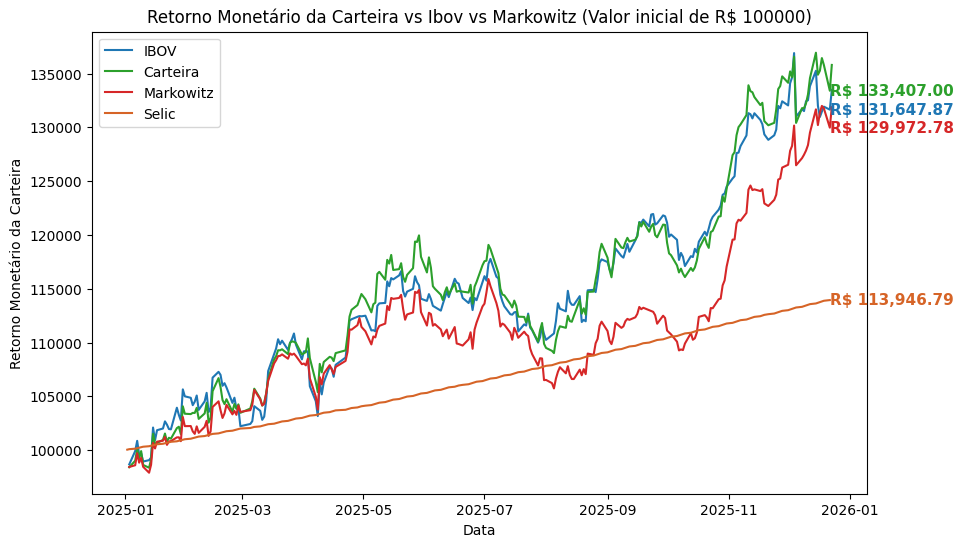

✅ Retornos acumulados salvos em: ../data/retornos_acumulados.csv



In [ ]:
carteira_tempo = comp.print_results()

In [ ]:

tics_selecionados = list(carteira_resultado['tickers_weights'].keys())

tics_selecionados_sa = [tic + ".SA" if not tic.endswith(".SA") else tic for tic in tics_selecionados]
print(tics_selecionados_sa)

df = yf.download(tics_selecionados_sa, start="2025-01-01")["Close"]

pesos = list(carteira_resultado['tickers_weights'].values()) 

comp = ComputandoMetricas("2025-01-01", "2025-12-31", tics_selecionados_sa, pesos, 100000)

#carteira_tempo = comp.print_results()

#carteira_tempo.to_csv("avaliacao_carteira.csv")

['ABEV3.SA', 'BBDC4.SA', 'BBAS3.SA', 'BRAP4.SA', 'CMIG3.SA', 'CSUD3.SA', 'EGIE3.SA', 'FIQE3.SA', 'WEGE3.SA']


C:\Users\jefer\AppData\Local\Temp\ipykernel_28464\3444372168.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tics_selecionados_sa, start="2025-01-01")["Close"]
[*********************100%***********************]  9 of 9 completed
C:\Users\jefer\AppData\Local\Temp\ipykernel_28464\1549867255.py:190: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ibov = yf.download("^BVSP", start=self.data_inicio, end=self.data_fim)["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\jefer\AppData\Local\Temp\ipykernel_28464\1549867255.py:191: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(self.tics_selecionados, start=self.data_inicio, end=self.data_fim)["Close"]
[*********************100%***********************]  9 of 9 completed


In [ ]:
carteira_tempo = comp.print_results()

In [ ]:
import json
import asyncio
import pandas as pd
from bcb import sgs
import pandas as pd
from sklearn.covariance import LedoitWolf
import numpy as np
from scipy.optimize import minimize
from IPython.display import display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import logging

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

    
def markowitz_opt(returns: pd.DataFrame):
    # === Estatísticas ===
    mu = returns.mean()  # retorno médio esperado
    # matriz de covariância com Ledoit–Wolf shrinkage
    lw = LedoitWolf().fit(returns)
    Sigma = lw.covariance_

    n = len(mu)

    # Retorno alvo (por exemplo, retorno médio da amostra de treino)
    target_return = mu.mean()

    # === Funções auxiliares ===
    def portfolio_performance(w, mu, Sigma):
        ret = np.dot(w, mu)
        vol = np.sqrt(np.dot(w.T, np.dot(Sigma, w)))
        return ret, vol

    def objective(w, mu, Sigma, target):
        ret, vol = portfolio_performance(w, mu, Sigma)
        return vol  # minimiza a volatilidade

    # === Restrições ===
    constraints = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},              # soma = 1
        {'type': 'eq', 'fun': lambda w: np.dot(w, mu) - target_return},  # retorno alvo
    )
    bounds = tuple((0, 1) for _ in range(n))  # sem short

    # === Otimização ===
    w0 = np.repeat(1/n, n)
    opt = minimize(
        objective, w0, args=(mu, Sigma, target_return),
        method='SLSQP', bounds=bounds, constraints=constraints
    )

    weights = opt.x

    # === Aplicação dos pesos ao conjunto de retornos ===
    markowitz_cr = (1 + (weights * returns).sum(axis=1)).cumprod()

    weights_markowitz = pd.DataFrame(
        np.tile(weights, (len(returns), 1)),  # repete o vetor em todas as linhas
        index=returns.index,
        columns=returns.columns
    )

    return weights_markowitz, markowitz_cr

def get_selic_multiplos_periodos(data_inicio, data_fim, anos_por_janela=5):
    """
    Busca dados da SELIC em janelas de X anos para contornar limitação da API
    """
    inicio = pd.to_datetime(data_inicio)
    fim = pd.to_datetime(data_fim)
    
    # Lista para armazenar os dataframes
    dados_completos = []
    
    # Criar janelas
    current_start = inicio
    
    while current_start < fim:
        current_end = min(current_start + pd.DateOffset(years=anos_por_janela), fim)
        
        print(f"Buscando dados de {current_start.date()} até {current_end.date()}...")
        
        try:
            # Fazer requisição para a janela atual
            dados_janela = sgs.get({'selic': 11, 
                                    #'cdi' :12
                                    }, 
                                   start=current_start.strftime('%Y-%m-%d'),
                                   end=current_end.strftime('%Y-%m-%d'))
            
            dados_completos.append(dados_janela)
            print(f"  ✓ {len(dados_janela)} registros obtidos")
            
        except Exception as e:
            print(f"  ✗ Erro ao buscar dados: {e}")

        current_start = current_end + pd.Timedelta(days=1)

    if dados_completos:
        selic_completo = pd.concat(dados_completos)
        selic_completo = selic_completo[~selic_completo.index.duplicated(keep='first')]
        selic_completo = selic_completo.sort_index()
        
        print(f"\n✓ Total de registros: {len(selic_completo)}")
        print(f"✓ Período: {selic_completo.index.min().date()} até {selic_completo.index.max().date()}")
        
        return selic_completo
    else:
        print("Nenhum dado foi obtido!")
        return None
    
def daily_returns(prices):
    return prices.pct_change()[1:]

def daily_returns_carteira(prices, pesos):
    pesos_porcentagem = pesos_porcentagem = [peso/100 for peso in pesos]
    variacao_diaria_carteira = (prices.pct_change()[1:] * (pesos_porcentagem)).sum(axis=1)
    return variacao_diaria_carteira

def annualized_volatility(daily_ret, trading_days=252):
    return daily_ret.std() * np.sqrt(trading_days)

def annualized_mean_return(daily_ret, trading_days=252):
    return daily_ret.mean() * trading_days

def cagr(prices):
    days = (prices.index[-1] - prices.index[0]).days
    years = days / 365.25
    return (prices.iloc[-1] / prices.iloc[0])**(1/years) - 1 if years > 0 else np.nan

def max_drawdown(prices):
    cum_max = prices.cummax()
    drawdowns = (prices - cum_max) / cum_max
    return drawdowns.min()

def avg_drawdown(prices):
    dd = (prices / prices.cummax()) - 1
    negatives = dd < 0
    groups = (negatives.astype(int).diff() != 0).cumsum()
    avg_dds = []
    for _, grp in dd.groupby(groups):
        if (grp < 0).any():
            avg_dds.append(grp.min())
    return np.mean(avg_dds) if avg_dds else 0.0

def calmar_ratio(prices):
    ann_ret = cagr(prices)
    mdd = max_drawdown(prices)
    return ann_ret / abs(mdd) if mdd != 0 else np.nan

def sortino_ratio(daily_ret, required_return=0.0, trading_days=252):
    rr_daily = (1 + required_return)**(1/trading_days) - 1
    downside = daily_ret[daily_ret < rr_daily] - rr_daily
    if downside.size == 0:
        return np.nan
    dd = np.sqrt((downside**2).mean()) * np.sqrt(trading_days)
    ann_ret = annualized_mean_return(daily_ret, trading_days)
    return (ann_ret - required_return) / dd if dd != 0 else np.nan

def compute_metrics(price_df):
    metrics = {}
    for col in price_df.columns:
        p = price_df[col].dropna()
        #dr = daily_returns_carteira(p, pesos)
        metrics[col] = {
            "ann_vol": annualized_volatility(p),
            "ann_mean_ret": annualized_mean_return(p),
            "cagr": cagr(p),
            "max_drawdown": max_drawdown(p),
            "avg_drawdown": avg_drawdown(p),
            "calmar": calmar_ratio(p),
            "sortino": sortino_ratio(p)
        }
    return pd.DataFrame(metrics).T


def normalizar_pesos(weights_dict, target_sum=100, tolerancia=0.01):
    """
    Normaliza os pesos para somarem exatamente o target_sum.
    
    Args:
        weights_dict: Dicionário com os pesos {ticker: peso}
        target_sum: Soma alvo (padrão: 100)
        tolerancia: Tolerância para considerar soma correta (padrão: 0.01)
    
    Returns:
        Dicionário com pesos normalizados
    """
    total_atual = sum(weights_dict.values())
    diferenca = abs(total_atual - target_sum)
    
    # Se já está dentro da tolerância, retorna o original
    if diferenca <= tolerancia:
        logger.info(f"✓ Pesos já somam {total_atual:.2f}% (dentro da tolerância)")
        return weights_dict
    
    # Normalização proporcional (melhor que distribuir igualmente)
    fator_normalizacao = target_sum / total_atual
    weights_normalizados = {
        ticker: peso * fator_normalizacao 
        for ticker, peso in weights_dict.items()
    }
    
    # Log da correção
    logger.warning(
        f"⚠ Pesos ajustados: {total_atual:.2f}% → {target_sum:.2f}% "
        f"(fator: {fator_normalizacao:.4f})"
    )
    
    # Verificação final
    soma_final = sum(weights_normalizados.values())
    logger.info(f"✓ Soma final: {soma_final:.4f}%")
    
    return weights_normalizados

class ComputandoMetricas:
    def __init__(self, data_inicio, 
                 data_fim, 
                 carteira,
                 valor_investido=1000):
        self.data_inicio = data_inicio
        self.data_fim = data_fim
        self.carteira = carteira
        self.valor_investido = valor_investido
        self.ibov, self.df = self.carregando_dados()
        self.tics_selecionados, self.pesos_carteira = self.ajustando_pesos_carteira()
    
        
    def carregando_dados(self):
        tics_selecionados = [tic if tic.endswith(".SA") else f"{tic}.SA" for tic in self.carteira.keys()]
        ibov = yf.download("^BVSP", start=self.data_inicio, end=self.data_fim)["Close"]
        df = yf.download(tics_selecionados, start=self.data_inicio, end=self.data_fim)["Close"]
        df.dropna(axis=1, how='all', inplace=True)
        return ibov, df
    
    def cumulative_returns(self):
        return (self.df.apply(daily_returns)+1).cumprod()
    
    def ajustando_pesos_carteira(self):
        dict_carteiras = self.carteira.copy()
        tic_validos = list(self.df.columns)
        carteira_valida = {
            key: value for key, value in dict_carteiras.items()
            if (key.endswith(".SA") and key in tic_validos) or 
            (not key.endswith(".SA") and key + ".SA" in tic_validos)
        }
        
        carteira_pesos_acoes_validos = normalizar_pesos(carteira_valida)
        tics_selecionados = list(carteira_pesos_acoes_validos.keys())
        pesos = list(carteira_pesos_acoes_validos.values()) 
        return tics_selecionados, pesos
        
    def computando_marcowitz(self):
        weights_markowitz, markowitz_cr = markowitz_opt(self.df.pct_change().dropna())
        return weights_markowitz, markowitz_cr
        
    def daily_returns_carteira_markowitz(self):
        weights_markowitz, markowitz_cr = self.computando_marcowitz()
        pesos_markowitz = [peso*100 for peso in weights_markowitz.iloc[-1].to_list()]
        retornos_carteira_markowitz = daily_returns_carteira(self.df, pesos_markowitz)
        return retornos_carteira_markowitz
    
    def retornos_diarios_carteira(self):
        retornos_diarios_carteira = daily_returns_carteira(self.df, self.pesos_carteira)
        return retornos_diarios_carteira
    
    def retornos_diarios_ibov(self):
        retorno_diario = self.ibov.pct_change()[1:]
        return retorno_diario
    
    def data_frame_comparacao_retorno_diario(self):
        retornos_carteira = self.retornos_diarios_carteira()
        retornos_ibov = self.retornos_diarios_ibov()
        retornos_markowitz = self.daily_returns_carteira_markowitz()
        comparacao_carteira = pd.concat([retornos_carteira, 
                                 retornos_ibov, 
                                 retornos_markowitz], axis=1,).rename(columns={0: "Carteira", 
                                                                               "^BVSP": "IBOV", 
                                                                               1: "Markowitz"})
        return comparacao_carteira
    
    def metrica_comparacao_carteira_ibov_retornos_markowitz(self):
        comparacao_carteira = self.data_frame_comparacao_retorno_diario()
        comp_metrics = compute_metrics(comparacao_carteira)
        return comp_metrics
    
    def retorno_menetario_ibov(self):
        ibov_retornos = (self.ibov.pct_change()[1:]+1).cumprod() *self.valor_investido
        return ibov_retornos
    
    def retorno_carteira_monetario(self):
        pesos_frac = [p/100 for p in self.pesos_carteira]
        valor_investido_carteira = [self.valor_investido * peso for peso in pesos_frac]
        retorno_carteira = (self.cumulative_returns() * valor_investido_carteira).sum(axis=1)
        return retorno_carteira
    
    def data_frame_comparacao_retorno_monetario(self):
        ibov_retornos = self.retorno_menetario_ibov()
        retorno_carteira = self.retorno_carteira_monetario()
        _ , markowitz_cr = self.computando_marcowitz()
        selic = self.retorno_selic()

        retorno_acumulado_monetario = pd.concat([ibov_retornos, retorno_carteira, markowitz_cr*self.valor_investido, selic], axis=1).rename(columns={"^BVSP": "IBOV", 0: "Carteira", 1: "Markowitz", "selic":"Selic"})
        return retorno_acumulado_monetario
    
    def retorno_selic(self):
        selic = get_selic_multiplos_periodos(self.data_inicio, self.data_fim)
        selic_acumulada =  ((selic/100 + 1).cumprod())*self.valor_investido
        return selic_acumulada
    
    def print_results(self, save_path="../data/"):
        import os
        from datetime import datetime
        
        # Criar diretório se não existir
        os.makedirs(save_path, exist_ok=True)
    
        
        metrics = self.metrica_comparacao_carteira_ibov_retornos_markowitz()
        retorno_acumulado_monetario = self.data_frame_comparacao_retorno_monetario()
        
        print("\n" + "="*40)
        print("📊 Métricas de Comparação das Carteiras")
        print("="*40)
        
        # Salvar métricas em CSV
        metrics_file = os.path.join(save_path, "metricas.csv")
        metrics.to_csv(metrics_file)
        print(f"✅ Métricas salvas em: {metrics_file}")
    
        display(metrics.style.set_caption("Métricas das Carteiras").background_gradient(cmap="Blues"))
    
        plt.figure(figsize=(10, 6))
        cores = {'IBOV': '#1f77b4', 'Carteira': '#2ca02c', 'Markowitz': '#d62728', 'Selic': "#d66427"}

        for nome in ['IBOV', 'Carteira', 'Markowitz', 'Selic']:
            plt.plot(
                retorno_acumulado_monetario.index,
                retorno_acumulado_monetario[nome],
                label=nome,
                color=cores[nome]
            )
            ultimo_x = retorno_acumulado_monetario.index[-2]
            ultimo_y = retorno_acumulado_monetario[nome].iloc[-2]
            plt.text(
                ultimo_x, ultimo_y,
                f'R$ {ultimo_y:,.2f}',
                color=cores[nome],
                fontsize=11,
                va='center',
                fontweight='bold'
            )

        plt.legend()
        plt.xlabel("Data")
        plt.ylabel("Retorno Monetário da Carteira")
        plt.title(f"Retorno Monetário da Carteira vs Ibov vs Markowitz (Valor inicial de R$ {self.valor_investido})")
        
        # Salvar gráfico
        grafico_file = os.path.join(save_path, f"grafico_retornos.png")
        plt.savefig(grafico_file, dpi=300, bbox_inches='tight')
        print(f"✅ Gráfico salvo em: {grafico_file}")
        
        plt.show()
        
        # Salvar retornos acumulados em CSV
        retornos_file = os.path.join(save_path, f"retornos_acumulados.csv")
        retorno_acumulado_monetario.to_csv(retornos_file)
        print(f"✅ Retornos acumulados salvos em: {retornos_file}")
        
        print("\n" + "="*40)
        
        return retorno_acumulado_monetario

with open("../data/carteira_resultado.json", "r") as f:
    carteira_resultado = json.load(f)
    
comp = ComputandoMetricas("2025-01-01", "2025-12-31",carteira_resultado['tickers_weights'] ,100000)

comp.print_results(save_path="../data/")

In [ ]:
pd_tic = pd.read_csv(
            "https://raw.githubusercontent.com/Jeferson100/fundamentalist-stock-brazil/main/dados/setor.csv"
        )
tics = pd_tic['tic'].unique().tolist()

In [ ]:
pd_tic['tic'].unique().tolist()

['AALR3',
 'ABEV3',
 'AFLT3',
 'AGRO3',
 'AGXY3',
 'AHEB3',
 'ALPA3',
 'ALPA4',
 'ALPK3',
 'ALLD3',
 'ALOS3',
 'AMBP3',
 'AMAR3',
 'AMER3',
 'ANIM3',
 'ASAI3',
 'AURE3',
 'AVLL3',
 'AZEV3',
 'AZUL4',
 'AZZA3',
 'BALM4',
 'BAUH4',
 'BAZA3',
 'BBAS3',
 'BBSE3',
 'BBDC3',
 'BBDC4',
 'BGIP3',
 'BGIP4',
 'BIOM3',
 'BLAU3',
 'BMEB3',
 'BMEB4',
 'BMKS3',
 'BMIN3',
 'BMIN4',
 'BMOB3',
 'BPAN4',
 'BPAC11',
 'BPAC3',
 'BPAC5',
 'BRAP3',
 'BRAP4',
 'BRAV3',
 'BRBI11',
 'BRKM3',
 'BRKM5',
 'BRST3',
 'BRSR3',
 'BRSR6',
 'BSLI3',
 'BSLI4',
 'CAMB3',
 'CAML3',
 'CASH3',
 'CEAB3',
 'CEBR6',
 'CEDO3',
 'CEDO4',
 'CGAS3',
 'CGAS5',
 'CGRA4',
 'CLSC4',
 'CMIG3',
 'CMIG4',
 'COGN3',
 'CSAN3',
 'CSMG3',
 'CSNA3',
 'CSUD3',
 'CYRE3',
 'DIRR3',
 'DXCO3',
 'EALT3',
 'EALT4',
 'ECOR3',
 'EGIE3',
 'ENEV3',
 'ENGI11',
 'ENGI3',
 'ENGI4',
 'EQTL3',
 'ESPA3',
 'EZTC3',
 'FESA3',
 'FESA4',
 'FIQE3',
 'FLRY3',
 'FRAS3',
 'FRIO3',
 'GGBR3',
 'GGBR4',
 'GOAU3',
 'GOAU4',
 'HAPV3',
 'HYPE3',
 'IGTI3',
 'IGTI11',
 'INTB

In [ ]:
with open("../data/results_tics.json", "r") as f:
    avaliacao_tics = json.load(f)


In [ ]:
avaliacao_tics

{'AALR3': {'classification': 'Poor',
  'analysis': 'AALR3 shows chronic negative net margin (-5% to -10%) and EPS below zero in most periods, indicating weak profitability. Financial leverage remains moderate (~2.5) but debt/EBITDA is high early (~5‑6) though improving later. Cash flow from operations is highly volatile, with large swings and occasional negative values. Valuation multiples are mixed but P/E is negative due to losses. Overall, the firm faces profitability challenges and elevated financial risk, warranting a Poor classification.',
  'tic': 'AALR3',
  'dados_fundamentalistas': '|    |   receita_liquida |   ebitda | lucro_por_acao   | datas               | tic   |   alavancagem_financeira |   margem_liquida |   preço_lucro |   preço_vpa |   fluxo_caixa_operacional |   divida_liquida_ebitda |   aumento_reducao_caixa_equivalentes |\n|---:|------------------:|---------:|:-----------------|:--------------------|:------|-------------------------:|-----------------:|------------

In [1]:
from portfolio_optimizer import BuildGraphAvaliacaoTics, BuildGraphCriadorCarteira, StateClassification, TratandoDadosFundamentalistas, DadosFundamentalistas, transformando_data_frame_para_markdown, StateCarteira

c:\Users\jefer\Documents\Ciencia-de-dados\LLMs\Agent-Portfolio-Optimizer\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from phoenix.otel import register
from openinference.instrumentation.langchain import LangChainInstrumentor
import os
tracer_provider = register(
  project_name="Agente-Criador-Carteira",
  endpoint="https://app.phoenix.arize.com/s/sehnemjeferson/v1/traces",
  auto_instrument=True,
  api_key=os.getenv("PHOENIX_API_KEY")
  
)

LangChainInstrumentor().instrument(tracer_provider=tracer_provider)

INFO:phoenix.config:📋 Ensuring phoenix working directory: C:\Users\jefer\.phoenix
INFO:phoenix.inferences.inferences:Dataset: phoenix_inferences_12166d63-0d93-45c2-a699-e0cbaa25d155 initialized


OpenTelemetry Tracing Details
|  Phoenix Project: Agente-Criador-Carteira
|  Span Processor: SimpleSpanProcessor
|  Collector Endpoint: https://app.phoenix.arize.com/s/sehnemjeferson/v1/traces
|  Transport: HTTP + protobuf
|  Transport Headers: {'authorization': '****'}
|  
|  Using a default SpanProcessor. `add_span_processor` will overwrite this default.
|  
|  WARNING: It is strongly advised to use a BatchSpanProcessor in production environments.
|  
|  `register` has set this TracerProvider as the global OpenTelemetry default.
|  To disable this behavior, call `register` with `set_global_tracer_provider=False`.



In [3]:
graph_tics = BuildGraphAvaliacaoTics()
graph_carteira = BuildGraphCriadorCarteira()

In [4]:
graph_build = graph_tics.compile()

graph_carteira_build = graph_carteira.compile()

In [5]:
tic = "AALR3"
data_inicio = "2014-01-01"
data_fim = "2015-12-31"
response = await graph_build.ainvoke(
            StateClassification(
                {
                    "tic": tic,
                    "data_inicio": data_inicio,
                    "data_fim": data_fim,
                    "avaliacao_analise": "",
                    "description_avaliacao_analise": "",
                    "interacao": 0,
                }
            )
        )

INFO:portfolio_optimizer.roteador_llms.roteador_llms:Iniciando roteamento LLM
INFO:portfolio_optimizer.roteador_llms.roteador_llms:🔄 Tentando provider_name=Nvidia...
INFO:portfolio_optimizer.roteador_llms.roteador_llms:Sucesso com modelo Nvidia: qwen/qwen3-235b-a22b
INFO:portfolio_optimizer.roteador_llms.roteador_llms:🔄 Tentando provider_name=Cerebras...
INFO:httpx:HTTP Request: GET https://api.cerebras.ai/v1/tcp_warming "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.cerebras.ai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
INFO:cerebras.cloud.sdk._base_client:Retrying request to /v1/chat/completions in 0.460630 seconds
INFO:httpx:HTTP Request: POST https://api.cerebras.ai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
INFO:cerebras.cloud.sdk._base_client:Retrying request to /v1/chat/completions in 0.893923 seconds
INFO:httpx:HTTP Request: POST https://api.cerebras.ai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
ERROR:portfolio_optimizer.roteador_llms.

In [6]:
response

{'classification': 'Excellent',
 'analysis': 'The company ranks at the top of the market, consistently delivering stronger financial performance than the sector average. It maintains low financial leverage, fairly high profitability, and consistently has stable earnings growth. These positive indicators coupled with its low debt and sustainable growth prospects warrant an excellent rating. It is a solid investment opportunity, both for high return rates and its long-term stability and growth potential.',
 'tic': 'AALR3',
 'dados_fundamentalistas': '| receita_liquida   | ebitda   | lucro_por_acao   | datas   | tic   | alavancagem_financeira   | margem_liquida   | preço_lucro   | preço_vpa   | fluxo_caixa_operacional   | divida_liquida_ebitda   | aumento_reducao_caixa_equivalentes   |\n|-------------------|----------|------------------|---------|-------|--------------------------|------------------|---------------|-------------|---------------------------|-------------------------|------

In [7]:
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from dotenv import load_dotenv

load_dotenv()

chat_nvidia = ChatNVIDIA(model="nvidia/nemotron-4-mini-hindi-4b-instruct")

In [8]:
chat_nvidia.invoke("Ola")

AIMessage(content='Olá! How can I assist you today?\n', additional_kwargs={}, response_metadata={'role': 'assistant', 'content': 'Olá! How can I assist you today?\n', 'token_usage': {'prompt_tokens': 13, 'total_tokens': 25, 'completion_tokens': 12}, 'finish_reason': 'stop', 'model_name': 'nvidia/nemotron-4-mini-hindi-4b-instruct'}, id='lc_run--238277d6-6c9a-4ded-a5cc-2d8d7953f58f-0', usage_metadata={'input_tokens': 13, 'output_tokens': 12, 'total_tokens': 25}, role='assistant')

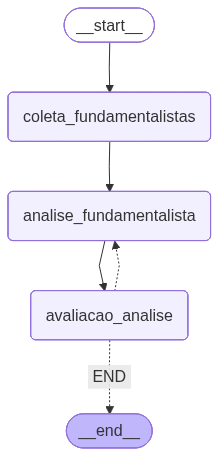

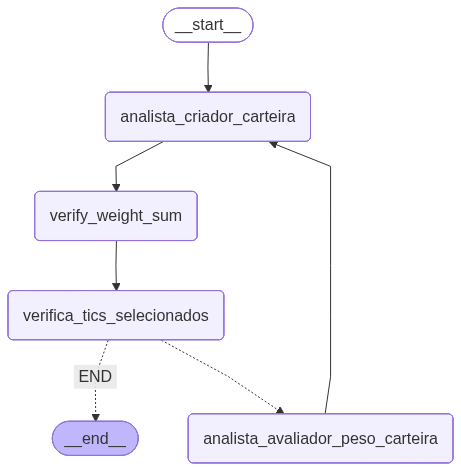

In [13]:
from IPython.display import Image, display  # Para notebooks

# Seu grafo compilado
png_bytes = graph_tics_build.get_graph().draw_mermaid_png()

png_bytes_carteira = graph_carteira_build.get_graph().draw_mermaid_png()

# Salvar em arquivo PNG
with open("../image/agente_avaliador_tics.png", "wb") as f:
    f.write(png_bytes)

with open("../image/agente_criador_carteira.png", "wb") as f:
    f.write(png_bytes_carteira)

# Opcional: exibir no notebook
display(Image(png_bytes))

display(Image(png_bytes_carteira))

In [2]:
import json
with open("../data/avaliacao_tics_historico_2015.json", "r") as f:
    carteira_resultado = json.load(f)

In [ ]:
carteira_resultado

In [4]:
with open("../data/results_tics.json", "r") as f:
    avaliacao_tics = json.load(f)

In [ ]:
avaliacao_tics

In [4]:
from portfolio_optimizer import TratandoDadosFundamentalistas
import pandas as pd

import logging

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

In [2]:
pd_tic = pd.read_csv(
            "https://raw.githubusercontent.com/Jeferson100/fundamentalist-stock-brazil/main/dados/setor.csv"
        )
tics = pd_tic['tic'].unique().tolist()

In [ ]:
import asyncio
async def coleta_dados_fundamentalistas(tic, data_inicio, data_fim):
    try:
        data_trat = TratandoDadosFundamentalistas(tic, data_inicio, data_fim)
        _ = await data_trat.coleta_dados_fundamentalistas()
        return tic
    except:
        logger.error(f"Erro ao processar {tic}")
        
    

async def verifica_tics_periodo(tics, data_inicio, data_fim):
    
    retorno_tics_possives = await asyncio.gather(*[coleta_dados_fundamentalistas(tic, data_inicio, data_fim) for tic in tics])
    return retorno_tics_possives
    
    
res = await verifica_tics_periodo(tics, "2014-04-01", "2016-01-01")
  

In [30]:
len([re for re in res if re is not None])

130

In [22]:
import json
with open("../data/avaliacao_tics_historico_2016.json", "r") as f:
    carteira_resultado = json.load(f)

In [ ]:
carteira_resultado

In [25]:
lista_tics = []
for tic in carteira_resultado['2014-04-01_to_2016-01-01']:
    if carteira_resultado['2014-04-01_to_2016-01-01'][tic] is not None:
        lista_tics.append(tic)

In [26]:
len(lista_tics)

29

In [ ]:
data_trat = TratandoDadosFundamentalistas("AALR3", "2015-01-01", "2015-12-01")
results = await data_trat.coleta_dados_fundamentalistas()